In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
import string
import numpy as np
from gensim.models import KeyedVectors
from collections import Counter
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.linear_model import LogisticRegression


In [2]:
# ! wget https://nlp.stanford.edu/data/glove.6B.zip
# ! unzip glove.6B.zip

In [3]:
df = pd.read_csv('news.csv')  

print(df.columns.tolist())

['Unnamed: 0', 'title', 'text', 'label']


In [4]:
#Show lables

df.drop_duplicates().groupby(df.label).size()

label
FAKE    3164
REAL    3171
dtype: int64

In [5]:
df['title_len'] = df.title.apply(lambda x: len(x.split(' ')))
df['text_len'] = df.text.apply(lambda x: len(x.split(' ')))  

In [6]:
from nltk.tokenize import TreebankWordTokenizer, ToktokTokenizer, TweetTokenizer
from tqdm import tqdm  #Progress bar


# Creat a list of tokenizers
tokenizers = [TreebankWordTokenizer(), ToktokTokenizer(), TweetTokenizer()]


for tok in tqdm(tokenizers):
    arr = df.text.drop_duplicates().apply(lambda x: tok.tokenize(x)).array

    # Flatten the list
    arr = [x for X in arr for x in X]
    


100%|██████████| 3/3 [00:48<00:00, 16.23s/it]


In [7]:
import re
from nltk.corpus import stopwords #Removes useless words like 'the', 'a', 'and'
from nltk.stem import PorterStemmer #Reduces words to root form
from nltk.tokenize import word_tokenize #splits sentences into words

In [8]:
import nltk
nltk.download('stopwords')
nltk.download('punkt')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\DELL\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\DELL\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [9]:
# Text preprocessing functions

stop_words = set(stopwords.words('english')) 
 
ps = PorterStemmer()

# bta5od el raw text, w bey return cleaned text string for TF-IDF
def preprocess_text(text):
    # Convert to lowercase
    text = text.lower()
    
    # Remove anything that is not a letter or space
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    
    # Tokenization
    tokens = word_tokenize(text)
    
    # Remove stopwords and stem
    tokens = [ps.stem(t) for t in tokens if t and t not in stop_words]
    
    return ' '.join(tokens) # bnraga3o tane l string 3l4an el TF-IDF bey expect a string
# TF_IDF needs a string because it counts characters/words.


# Apply to dataset
df['clean_text'] = df['text'].apply(preprocess_text)

# cleans text For LSTM, returns tokens as list (requires list of integers not a string)
def tokenize_for_embeddings(text):
    if not isinstance(text, str):
        return [] # law el input m4 string, bey return an empty list
    text = text.lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    tokens = word_tokenize(text)
    return [ps.stem(t) for t in tokens if t and t not in stop_words]
# LSTM by7tag list of tokens (after converting words to indicies)
# LSTM needs a list of tokens because it needs to preserve word order

df['tokens'] = df['text'].apply(tokenize_for_embeddings) # This creates 'tokens' column containing lists of cleaned words.

In [10]:
# ============================================
# TF-IDF FEATURE EXTRACTION (Term Frequency-Inverse Document Frequency)
# ============================================


from sklearn.feature_extraction.text import TfidfVectorizer 
from sklearn.model_selection import train_test_split

# Split data FIRST
X_train, X_test, y_train, y_test = train_test_split(
    df['clean_text'],   
    df['label'],        
    test_size=0.2,      
    random_state=42     
)

# We split before vectorizing 3l4an n prevent data leakage (eno my2asar4 3la el vocab aw el idf calculations)

# Create TF-IDF vectorizer (converts texts into numerical fearures based on word importance)
tfidf_vectorizer = TfidfVectorizer(
    max_features=5000,      
    ngram_range=(1, 2),     
    stop_words='english'    
)


X_train_tfidf = tfidf_vectorizer.fit_transform(X_train) 
X_test_tfidf = tfidf_vectorizer.transform(X_test)



In [11]:
# ============================================
# BASELINE MODEL: Logistic Regression 
# ============================================

# Train on TF-IDF features
baseline_model = LogisticRegression(max_iter=1000, random_state=42) #create the model
baseline_model.fit(X_train_tfidf, y_train) #train the model

# Predict
y_pred_baseline = baseline_model.predict(X_test_tfidf)

# Evaluation
print("BASELINE MODEL (Logistic Regression + TF-IDF)")
print(f"Accuracy: {accuracy_score(y_test, y_pred_baseline)*100:.2f}%")




BASELINE MODEL (Logistic Regression + TF-IDF)
Accuracy: 91.40%


In [12]:
# Evaluation


# Calculate metrics
accuracy_baseline = accuracy_score(y_test, y_pred_baseline)
precision_baseline = precision_score(y_test, y_pred_baseline, pos_label='REAL')
recall_baseline = recall_score(y_test, y_pred_baseline, pos_label='REAL')
f1_baseline = f1_score(y_test, y_pred_baseline, pos_label='REAL')

print("="*50)
print("BASELINE MODEL - Evaluation")
print("="*50)
print(f"Accuracy:  {accuracy_baseline*100:.2f}%")
print(f"Precision: {precision_baseline*100:.2f}%")
print(f"Recall:    {recall_baseline*100:.2f}%")
print(f"F1-Score:  {f1_baseline*100:.2f}%")

BASELINE MODEL - Evaluation
Accuracy:  91.40%
Precision: 92.06%
Recall:    90.77%
F1-Score:  91.41%


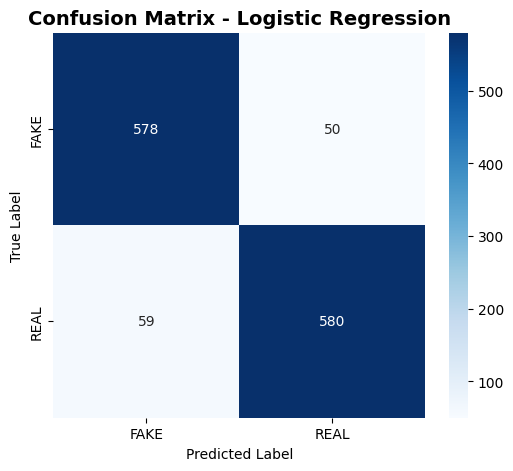

In [13]:
# ============================================
# CONFUSION MATRIX - BASELINE MODEL
# ============================================

cm_baseline = confusion_matrix(y_test, y_pred_baseline)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_baseline, annot=True, fmt='d', cmap='Blues',
            xticklabels=['FAKE', 'REAL'],
            yticklabels=['FAKE', 'REAL'])
plt.title('Confusion Matrix - Logistic Regression', fontsize=14, fontweight='bold')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

In [14]:
# ============================================
# ADVANCED MODEL: LSTM (Long Short-Term Memory)
# ============================================

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, Bidirectional
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences



# Creates a tokenizer that will only keep the top 10,000 most frequent words
# Any word not in top 10,000 gets replaced with an "unknown" token (usually 1 or OOV token)

# Prepare sequences for LSTM
tokenizer = Tokenizer(num_words=10000) #create tokenizer
tokenizer.fit_on_texts(X_train)


X_train_seq = tokenizer.texts_to_sequences(X_train) # Converts each training article from words to a list of integers
X_test_seq = tokenizer.texts_to_sequences(X_test) #Converts test articles to integer sequences using the SAME mapping from training.


# by5ly kol el articles the same lengths
# Pad sequences
max_length = 200
X_train_pad = pad_sequences(X_train_seq, 
                             maxlen=max_length,
                             padding='post', 
                             truncating='post')  

X_test_pad = pad_sequences(X_test_seq,
                            maxlen=max_length,
                            padding='post',
                            truncating='post')


In [15]:
# =============================================================
# GloVe Embeddings (Global Vectors) for Word Representation
# =============================================================


def load_glove_embeddings(file_path='glove.6B.100d.txt'):
    # Load GloVe embeddings into a dictionary
    embeddings_index = {} 


    with open(file_path, encoding='utf-8') as f: 
        for line in f: 
            values = line.split() 
            word = values[0] 
            coefs = np.asarray(values[1:], dtype='float32')
            embeddings_index[word] = coefs  
            
    print(f"Loaded {len(embeddings_index)} word vectors")
    return embeddings_index

# Load the embeddings
glove_embeddings = load_glove_embeddings('glove.6B.100d.txt') 

Loaded 400000 word vectors


In [16]:

# ( tokenizer is already fit on your training data)

embedding_dim = 100  # Must match the GloVe file you downloaded
vocab_size = len(tokenizer.word_index) + 1  # +1 for padding (index 0)
#  tokenizer have 52,266 unique words

# Initialize embedding matrix with zeros
embedding_matrix = np.zeros((vocab_size, embedding_dim))


# Fill the matrix with GloVe vectors where available
for word, i in tokenizer.word_index.items(): 
    embedding_vector = glove_embeddings.get(word) 
    if embedding_vector is not None:
        embedding_matrix[i] = embedding_vector 


print(f"Embedding matrix shape: {embedding_matrix.shape}") 

Embedding matrix shape: (52267, 100)


In [17]:
# Build LSTM with pre-trained GloVe embeddings


lstm_model = Sequential([ # Creates a Sequential model - a linear stack of layers where data flows from first layer to last layer.
    
    # Embedding layer with pre-trained GloVe weights
    Embedding(
        input_dim=vocab_size, 
        output_dim=embedding_dim, 
        weights=[embedding_matrix],  # <- GLOVE WEIGHTS GO HERE 
        input_length=max_length, 
        trainable=True  #  Allow embeddings to be fine-tuned during training
    ),
    Bidirectional(LSTM(128, dropout=0.3, recurrent_dropout=0.3, return_sequences=False)),
    Dense(64, activation='relu'), # 64 ==> Number of neurons (intermediate representation size) , activation	'relu'	Activation function (max(0, x))
    Dropout(0.5), # Randomly turns off 50% of neurons during training
    Dense(1, activation='sigmoid') # 1 ==> Binary classification (FAKE or REAL) , activation ==> 'sigmoid' ==> Squashes output to probability between 0 and 1
])


lstm_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])


C:\Users\DELL\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\core\embedding.py:103: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [18]:
# ============================================
# CONVERT LABELS TO NUMERIC
# ============================================

# Check current label values
print(f"Original labels: {y_train.unique()}")

# Convert to numeric (FAKE -> 0, REAL -> 1)
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
y_train_numeric = label_encoder.fit_transform(y_train)
y_test_numeric = label_encoder.transform(y_test)

# Verify conversion
print(f"Numeric labels: {set(y_train_numeric)}")
print(f"Mapping: FAKE={label_encoder.transform(['FAKE'])[0]}, REAL={label_encoder.transform(['REAL'])[0]}")

Original labels: ['REAL' 'FAKE']
Numeric labels: {np.int64(0), np.int64(1)}
Mapping: FAKE=0, REAL=1


In [19]:
# Train LSTM with numeric labels

history = lstm_model.fit( 
    X_train_pad, y_train_numeric,
    epochs=5, 
    batch_size=32, 
    validation_split=0.2, 
    verbose=1
)



Epoch 1/5
127/127 ━━━━━━━━━━━━━━━━━━━━ 52s 367ms/step - accuracy: 0.7242 - loss: 0.5295 - val_accuracy: 0.8245 - val_loss: 0.3821
Epoch 2/5
127/127 ━━━━━━━━━━━━━━━━━━━━ 50s 393ms/step - accuracy: 0.8648 - loss: 0.3247 - val_accuracy: 0.8767 - val_loss: 0.2994
Epoch 3/5
127/127 ━━━━━━━━━━━━━━━━━━━━ 53s 418ms/step - accuracy: 0.9139 - loss: 0.2249 - val_accuracy: 0.8925 - val_loss: 0.2688
Epoch 4/5
127/127 ━━━━━━━━━━━━━━━━━━━━ 52s 410ms/step - accuracy: 0.9460 - loss: 0.1456 - val_accuracy: 0.9014 - val_loss: 0.2559
Epoch 5/5
127/127 ━━━━━━━━━━━━━━━━━━━━ 52s 409ms/step - accuracy: 0.9615 - loss: 0.1071 - val_accuracy: 0.9073 - val_loss: 0.2623


In [20]:
# Evaluate
loss, accuracy = lstm_model.evaluate(X_test_pad, y_test_numeric)
print(f"LSTM Accuracy: {accuracy * 100:.1f}%")

40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 58ms/step - accuracy: 0.9195 - loss: 0.2304
LSTM Accuracy: 91.9%


In [21]:
# ============================================
# LSTM EVALUATION 
# ============================================

# Get predictions
y_pred_lstm_numeric = (lstm_model.predict(X_test_pad) > 0.5).astype(int).flatten()

# Calculate metrics using the predictions
accuracy_lstm = accuracy_score(y_test_numeric, y_pred_lstm_numeric)
precision_lstm = precision_score(y_test_numeric, y_pred_lstm_numeric)
recall_lstm = recall_score(y_test_numeric, y_pred_lstm_numeric)
f1_lstm = f1_score(y_test_numeric, y_pred_lstm_numeric)

print("LSTM Metrics:")
print(f"Accuracy: {accuracy_lstm*100:.2f}%")
print(f"Precision: {precision_lstm*100:.2f}%")
print(f"Recall: {recall_lstm*100:.2f}%")
print(f"F1-Score: {f1_lstm*100:.2f}%")


40/40 ━━━━━━━━━━━━━━━━━━━━ 3s 65ms/step
LSTM Metrics:
Accuracy: 91.95%
Precision: 92.02%
Recall: 92.02%
F1-Score: 92.02%


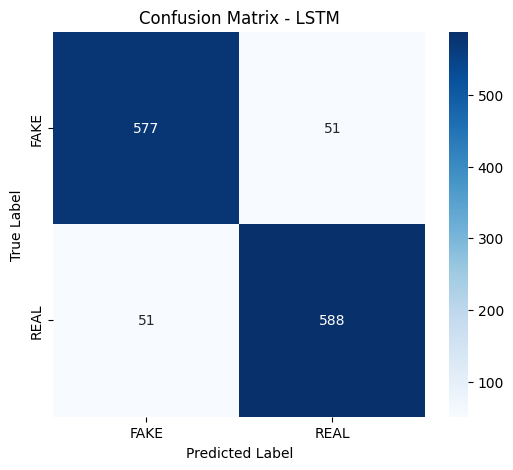

In [22]:
# Confusion matrix

cm_lstm = confusion_matrix(y_test_numeric, y_pred_lstm_numeric)
# print("\nLSTM Confusion Matrix:")
# print(cm_lstm)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_lstm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.title('Confusion Matrix - LSTM')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()


In [23]:
# ============================================
# EXTRA ADVANCED MODEL: BERT
# (Bidirectional Encoder Representations from Transformers)
# ============================================

from transformers import DistilBertTokenizer, DistilBertForSequenceClassification
from torch.utils.data import Dataset, DataLoader
import torch
import torch.nn.functional as F
from torch.optim import AdamW
from tqdm.notebook import tqdm
import gc



In [24]:
X_text = df['text'].values
y_labels = df['label'].values


In [25]:
# 3. Split data
X_train_bert, X_test_bert, y_train_bert, y_test_bert = train_test_split(
    X_text, y_labels, test_size=0.2, random_state=42
)

In [26]:
# 4. Encode labels
label_encoder = LabelEncoder()
y_train_bert_num = label_encoder.fit_transform(y_train_bert)
y_test_bert_num = label_encoder.transform(y_test_bert)

print(f"Train: {len(X_train_bert)}, Test: {len(X_test_bert)}")


Train: 5068, Test: 1267


In [27]:
# 5. Load DistilBERT (no sentencepiece needed!)
MODEL_NAME = 'distilbert-base-uncased'
MAX_LEN = 64
BATCH_SIZE = 8
EPOCHS = 3

print(f"Loading {MODEL_NAME}...")
bert_tokenizer = DistilBertTokenizer.from_pretrained(MODEL_NAME)
model = DistilBertForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2)
print(f"✓ Model loaded. Parameters: {sum(p.numel() for p in model.parameters()) / 1e6:.1f}M")

Loading distilbert-base-uncased...


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


✓ Model loaded. Parameters: 67.0M


In [28]:
# 6. Dataset class
class NewsDataset(Dataset):
    def __init__(self, texts, labels, bert_tokenizer, max_len):
        self.texts = texts
        self.labels = labels
        self.bert_tokenizer = bert_tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.bert_tokenizer(
            str(self.texts[idx]),
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        return {
            'input_ids': encoding['input_ids'].squeeze(),
            'attention_mask': encoding['attention_mask'].squeeze(),
            'labels': torch.tensor(self.labels[idx], dtype=torch.long)
        }


In [29]:
# 7. Create data loaders
train_dataset = NewsDataset(X_train_bert, y_train_bert_num, bert_tokenizer, MAX_LEN)
test_dataset = NewsDataset(X_test_bert, y_test_bert_num, bert_tokenizer, MAX_LEN)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE)

print(f"Train batches: {len(train_loader)}, Test batches: {len(test_loader)}")

Train batches: 634, Test batches: 159


In [30]:
# 8. Setup device and optimizer
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

if torch.cuda.is_available():
    print(f"GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

model.to(device)
optimizer = AdamW(model.parameters(), lr=2e-5, weight_decay=0.01)

Using device: cuda
GPU Memory: 4.3 GB


In [31]:
# 9. Training loop
train_losses = []
GRADIENT_ACCUMULATION_STEPS = 2

print("\nStarting training...")
for epoch in range(EPOCHS):
    model.train()
    total_loss = 0
    optimizer.zero_grad()
    
    progress_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS}")
    
    for i, batch in enumerate(progress_bar):
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)
        
        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=labels
        )
        
        loss = outputs.loss / GRADIENT_ACCUMULATION_STEPS
        loss.backward()
        
        total_loss += loss.item() * GRADIENT_ACCUMULATION_STEPS
        
        if (i + 1) % GRADIENT_ACCUMULATION_STEPS == 0:
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            optimizer.zero_grad()
        
        progress_bar.set_postfix({'loss': f'{loss.item() * GRADIENT_ACCUMULATION_STEPS:.4f}'})
    
    avg_loss = total_loss / len(train_loader)
    train_losses.append(avg_loss)
    print(f"Epoch {epoch+1}/{EPOCHS} | Avg Loss: {avg_loss:.4f}")
    
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

print("Training complete!")


Starting training...


Epoch 1/3:   0%|          | 0/634 [00:00<?, ?it/s]

Epoch 1/3 | Avg Loss: 0.2501


Epoch 2/3:   0%|          | 0/634 [00:00<?, ?it/s]

Epoch 2/3 | Avg Loss: 0.0892


Epoch 3/3:   0%|          | 0/634 [00:00<?, ?it/s]

Epoch 3/3 | Avg Loss: 0.0414
Training complete!


In [32]:
# 10. Evaluation
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for batch in tqdm(test_loader, desc="Evaluating"):
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels']
        
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        preds = torch.argmax(outputs.logits, dim=1)
        
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())


Evaluating:   0%|          | 0/159 [00:00<?, ?it/s]

In [33]:
# 11. Metrics
accuracy_bert = accuracy_score(all_labels, all_preds)
precision_bert = precision_score(all_labels, all_preds)
recall_bert = recall_score(all_labels, all_preds)
f1_bert = f1_score(all_labels, all_preds)

print("\n" + "="*50)
print("BERT (DistilBERT) Results")
print("="*50)
print(f"Accuracy:  {accuracy_bert*100:.2f}%")
print(f"Precision: {precision_bert*100:.2f}%")
print(f"Recall:    {recall_bert*100:.2f}%")
print(f"F1-Score:  {f1_bert*100:.2f}%")


BERT (DistilBERT) Results
Accuracy:  96.61%
Precision: 95.71%
Recall:    97.65%
F1-Score:  96.67%


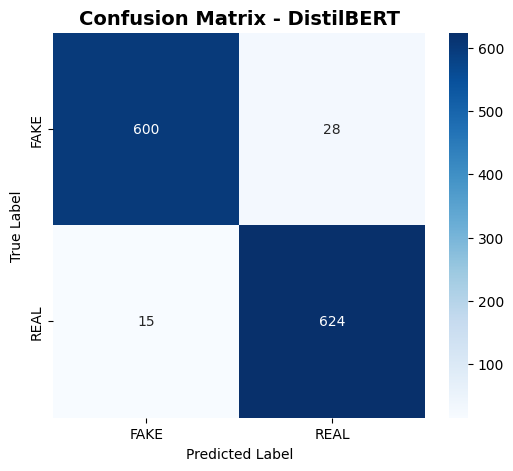

In [34]:
# 12. Confusion Matrix
cm_bert = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_bert, annot=True, fmt='d', cmap='Blues',
            xticklabels=['FAKE', 'REAL'],
            yticklabels=['FAKE', 'REAL'])
plt.title('Confusion Matrix - DistilBERT', fontsize=14, fontweight='bold')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

In [35]:
# ============================================
# MODEL COMPARISON 
# ============================================


print("MODEL COMPARISON:")

# Create comparison table
comparison_data = {
    'Model': ['Logistic Regression', 'LSTM (GloVe)', 'BERT (DistilBERT)'],
    'Accuracy': [f"{accuracy_baseline*100:.2f}%", f"{accuracy_lstm*100:.2f}%", f"{accuracy_bert*100:.2f}%"],
    'Precision': [f"{precision_baseline*100:.2f}%", f"{precision_lstm*100:.2f}%", f"{precision_bert*100:.2f}%"],
    'Recall': [f"{recall_baseline*100:.2f}%", f"{recall_lstm*100:.2f}%", f"{recall_bert*100:.2f}%"],
    'F1-Score': [f"{f1_baseline*100:.2f}%", f"{f1_lstm*100:.2f}%", f"{f1_bert*100:.2f}%"]
}

comparison_df = pd.DataFrame(comparison_data)
print(comparison_df.to_string(index=False))





MODEL COMPARISON:
              Model Accuracy Precision Recall F1-Score
Logistic Regression   91.40%    92.06% 90.77%   91.41%
       LSTM (GloVe)   91.95%    92.02% 92.02%   92.02%
  BERT (DistilBERT)   96.61%    95.71% 97.65%   96.67%


In [36]:
# ============================================
# SIMPLE TEST: ORIGINAL MODEL
# ============================================

def predict_news(text): 
    clean = preprocess_text(text)
    features = tfidf_vectorizer.transform([clean]) 

    real_probability = baseline_model.predict_proba(features)[0][1] # Gets the probability that this article is REAL news.
    prediction = "REAL" if real_probability > 0.5 else "FAKE" # Converts probability to a class label using 0.5 threshold.
    return prediction, real_probability

# Test a few examples
test_articles = [
    ("President Biden signs Inflation Reduction Act into law at White House ceremony", "REAL"),
    ("You won't believe this shocking discovery", "FAKE"),
    ("Breaking news!!!!", "FAKE"),
]

for text, expected in test_articles:
    pred, prob = predict_news(text)
    print(f"Text: {text}")
    print(f"Expected: {expected} | Predicted: {pred} | REAL prob: {prob:.3f}")
    print("-" * 50)



Text: President Biden signs Inflation Reduction Act into law at White House ceremony
Expected: REAL | Predicted: REAL | REAL prob: 0.539
--------------------------------------------------
Text: You won't believe this shocking discovery
Expected: FAKE | Predicted: FAKE | REAL prob: 0.195
--------------------------------------------------
Text: Breaking news!!!!
Expected: FAKE | Predicted: FAKE | REAL prob: 0.133
--------------------------------------------------


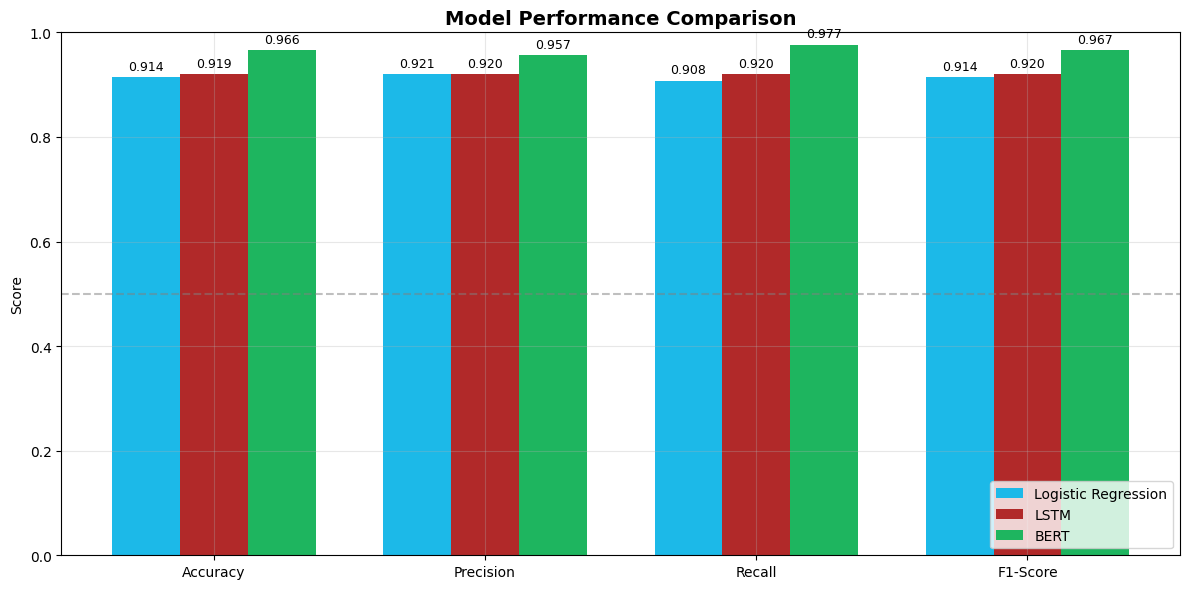

In [37]:
# ============================================
# COMBINED BAR CHART - ALL MODELS
# ============================================

metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
baseline_scores = [accuracy_baseline, precision_baseline, recall_baseline, f1_baseline]
lstm_scores = [accuracy_lstm, precision_lstm, recall_lstm, f1_lstm]
bert_scores = [accuracy_bert, precision_bert, recall_bert, f1_bert]

x = np.arange(len(metrics))
width = 0.25

fig, ax = plt.subplots(figsize=(12, 6))
rects1 = ax.bar(x - width, baseline_scores, width, label='Logistic Regression', color="#1CB9E8")
rects2 = ax.bar(x, lstm_scores, width, label='LSTM', color="#b12929")
rects3 = ax.bar(x + width, bert_scores, width, label='BERT', color="#1eb55f")

ax.set_ylabel('Score')
ax.set_title('Model Performance Comparison', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.legend(loc='lower right')
ax.set_ylim(0, 1)
ax.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5)
ax.grid(True, alpha=0.3)

# Add value labels on bars
for rect in rects1:
    height = rect.get_height()
    ax.annotate(f'{height:.3f}', xy=(rect.get_x() + rect.get_width()/2, height),
                xytext=(0, 3), textcoords="offset points", ha='center', va='bottom', fontsize=9)

for rect in rects2:
    height = rect.get_height()
    ax.annotate(f'{height:.3f}', xy=(rect.get_x() + rect.get_width()/2, height),
                xytext=(0, 3), textcoords="offset points", ha='center', va='bottom', fontsize=9)

for rect in rects3:
    height = rect.get_height()
    ax.annotate(f'{height:.3f}', xy=(rect.get_x() + rect.get_width()/2, height),
                xytext=(0, 3), textcoords="offset points", ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

In [38]:
# ============================================
# PATTERN EXTRACTION 
# ============================================


# 1. Simple statistics

print("DATASET STATISTICS")
print(f"Total articles: {len(df)}")
print(f"FAKE news: {(df['label'] == 'FAKE').sum()} ({(df['label'] == 'FAKE').mean()*100:.1f}%)")
print(f"REAL news: {(df['label'] == 'REAL').sum()} ({(df['label'] == 'REAL').mean()*100:.1f}%)")

# 2. Common patterns in FAKE news
fake_words = []
for tokens in df[df['label'] == 'FAKE']['tokens']:
    fake_words.extend(tokens)

fake_patterns = Counter(fake_words).most_common(10)
print("\n COMMON PATTERNS IN FAKE NEWS:")
for word, count in fake_patterns:
    print(f"   • '{word}': {count} times")

# 3. Common patterns in REAL news
real_words = []
for tokens in df[df['label'] == 'REAL']['tokens']:
    real_words.extend(tokens)

real_patterns = Counter(real_words).most_common(10)
print("\n COMMON PATTERNS IN REAL NEWS:")
for word, count in real_patterns:
    print(f"   • '{word}': {count} times")




DATASET STATISTICS
Total articles: 6335
FAKE news: 3164 (49.9%)
REAL news: 3171 (50.1%)

 COMMON PATTERNS IN FAKE NEWS:
   • 'clinton': 7077 times
   • 'us': 6879 times
   • 'trump': 6621 times
   • 'peopl': 5526 times
   • 'state': 5447 times
   • 'one': 5230 times
   • 'would': 4887 times
   • 'hillari': 4557 times
   • 'like': 4117 times
   • 'elect': 4071 times

 COMMON PATTERNS IN REAL NEWS:
   • 'said': 17187 times
   • 'trump': 15470 times
   • 'clinton': 10790 times
   • 'state': 10025 times
   • 'republican': 8064 times
   • 'would': 7780 times
   • 'presid': 6842 times
   • 'say': 6640 times
   • 'one': 6634 times
   • 'peopl': 6303 times


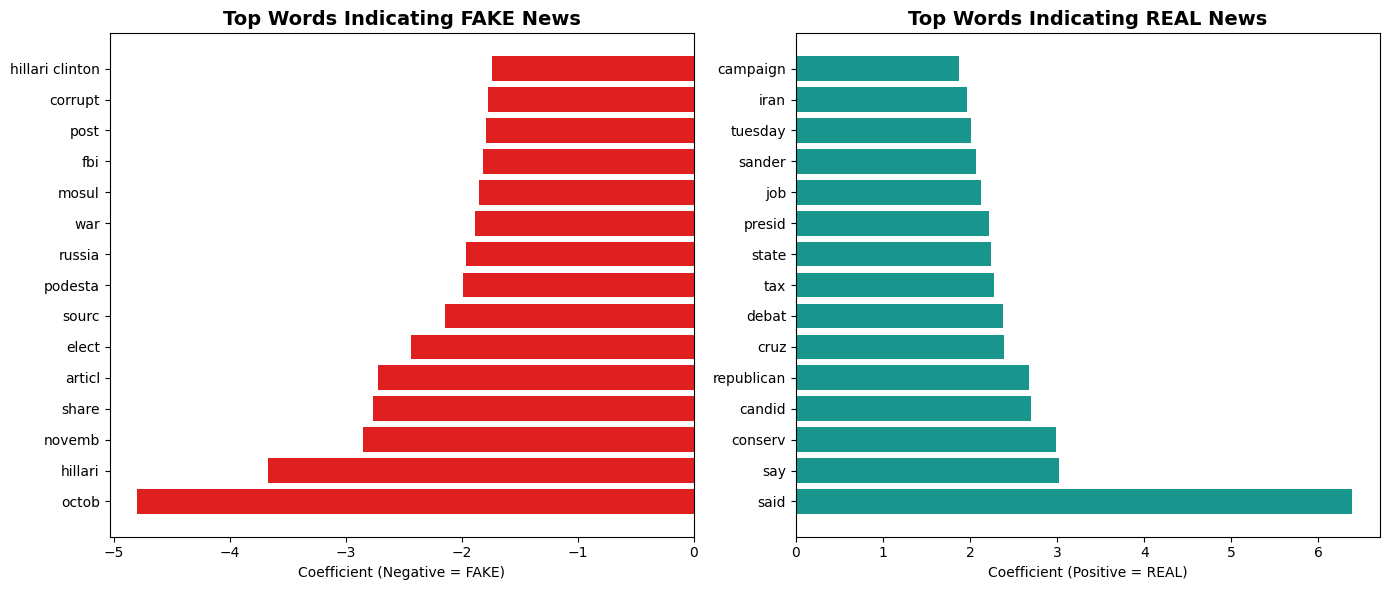

In [39]:
# ============================================
# FEATURE IMPORTANCE - TOP WORDS PLOT
# ============================================


# Get feature names and coefficients
feature_names = tfidf_vectorizer.get_feature_names_out()
coefficients = baseline_model.coef_[0]

# Get top 15 positive (REAL) and negative (FAKE) coefficients
top_real_idx = np.argsort(coefficients)[-15:][::-1]
top_fake_idx = np.argsort(coefficients)[:15]

top_real_words = [feature_names[i] for i in top_real_idx]
top_real_coef = [coefficients[i] for i in top_real_idx]
top_fake_words = [feature_names[i] for i in top_fake_idx]
top_fake_coef = [coefficients[i] for i in top_fake_idx]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# FAKE news indicators (negative coefficients)
ax1.barh(top_fake_words, top_fake_coef, color="#e02020")
ax1.set_title('Top Words Indicating FAKE News', fontsize=14, fontweight='bold')
ax1.set_xlabel('Coefficient (Negative = FAKE)')
ax1.axvline(x=0, color='black', linestyle='-', linewidth=0.5)

# REAL news indicators (positive coefficients)
ax2.barh(top_real_words, top_real_coef, color="#18958d")
ax2.set_title('Top Words Indicating REAL News', fontsize=14, fontweight='bold')
ax2.set_xlabel('Coefficient (Positive = REAL)')
ax2.axvline(x=0, color='black', linestyle='-', linewidth=0.5)

plt.tight_layout()
plt.show()

WORD CLOUD - Most Common Words


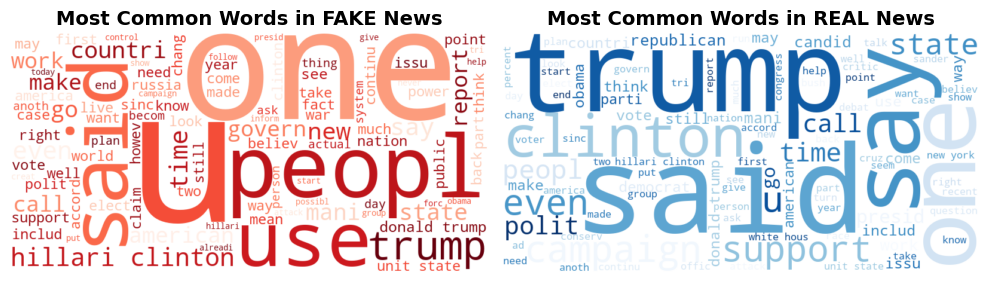

In [40]:

# ============================================
# WORD CLOUD - Most Common Words
# ============================================

from wordcloud import WordCloud



print("WORD CLOUD - Most Common Words")


# Create subplots
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Word cloud for FAKE news
fake_text = ' '.join(df[df['label'] == 'FAKE']['clean_text'].astype(str))
wordcloud_fake = WordCloud(width=800, height=400, 
                           background_color='white',
                           colormap='Reds',
                           max_words=100).generate(fake_text)

axes[0].imshow(wordcloud_fake, interpolation='bilinear')
axes[0].set_title('Most Common Words in FAKE News', fontsize=14, fontweight='bold')
axes[0].axis('off')

# Word cloud for REAL news
real_text = ' '.join(df[df['label'] == 'REAL']['clean_text'].astype(str))
wordcloud_real = WordCloud(width=800, height=400, 
                           background_color='white',
                           colormap='Blues',
                           max_words=100).generate(real_text)

axes[1].imshow(wordcloud_real, interpolation='bilinear')
axes[1].set_title('Most Common Words in REAL News', fontsize=14, fontweight='bold')
axes[1].axis('off')

plt.tight_layout()
plt.show()

In [41]:
import joblib
import pickle

# Save Logistic Regression + TF-IDF
joblib.dump(baseline_model, 'model.pkl')
joblib.dump(tfidf_vectorizer, 'vectorizer.pkl')
print("✅ Logistic Regression model saved!")

# Save LSTM + tokenizer
lstm_model.save('lstm_model.h5')
with open('tokenizer.pkl', 'wb') as f:
    pickle.dump(tokenizer, f)
print("✅ LSTM model saved!")

# Save BERT (DistilBERT) + tokenizer
model.save_pretrained('bert_model')
bert_tokenizer.save_pretrained('bert_tokenizer')
print("✅ BERT model saved!")

# Save the label encoder (needed for BERT predictions)
joblib.dump(label_encoder, 'label_encoder.pkl')
print("✅ Label encoder saved!")

✅ Logistic Regression model saved!
✅ LSTM model saved!


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✅ BERT model saved!
✅ Label encoder saved!
